In [2]:
#step 1: paths + load saved RF artefacts

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import joblib

#pathway
BASE_DIR = "/content/drive/MyDrive/AI4"

#raw TF5 file location
TF5_JSONL_PATH = os.path.join(BASE_DIR, "Raw", "train_features_5.jsonl")

#saved model artefacts from your RF folder
RF_DIR = os.path.join(BASE_DIR, "Models", "RF")
TOP50_PATH = os.path.join(RF_DIR, "top50_features.json")
MODEL_PATH = os.path.join(RF_DIR, "rf_final_top50.joblib")

#load top 50 selected feature names
with open(TOP50_PATH, "r") as f:
    top50_features = json.load(f)

#load trained RF model
rf_model = joblib.load(MODEL_PATH)

print("TF5 path exists:", os.path.exists(TF5_JSONL_PATH))
print("Top50 path exists:", os.path.exists(TOP50_PATH))
print("Model path exists:", os.path.exists(MODEL_PATH))
print("Number of selected features:", len(top50_features))
print("First 5 selected features:", top50_features[:5])
print("Loaded model:", type(rf_model))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF5 path exists: True
Top50 path exists: True
Model path exists: True
Number of selected features: 50
First 5 selected features: ['str.entropy', 'gen.imports', 'hdr.coff.timestamp', 'str.avlength', 'hdr.optional.sizeof_code']
Loaded model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [3]:
#step 2: load only a small sample from TF5 to inspect structure safely

import pandas as pd

sample_size = 2000  #small sample

df_tf5_sample = pd.read_json(
    TF5_JSONL_PATH,
    lines=True,
    nrows=sample_size
)

print("TF5 sample shape:", df_tf5_sample.shape)
print("\nColumns:")
print(df_tf5_sample.columns.tolist())

print("\nLabel distribution in sample:")
print(df_tf5_sample["label"].value_counts(dropna=False))

df_tf5_sample.head(2)

TF5 sample shape: (2000, 14)

Columns:
['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']

Label distribution in sample:
label
 1    841
 0    594
-1    565
Name: count, dtype: int64


,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
0,c31950077f3dc66b0decad88326773cb74102c0da3007d...,ba2d2b60b02cf229acd85a66284b3e43,2018-09,1,high,"[39415, 6597, 5938, 5563, 5578, 6479, 5484, 47...","[14336, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","{'numstrings': 6134, 'avlength': 5.66856863384...","{'size': 1353344, 'vsize': 3784704, 'has_debug...","{'coff': {'timestamp': 1308078076, 'machine': ...","{'entry': '', 'sections': [{'name': '', 'size'...","{'kernel32.dll': ['GetModuleHandleA'], 'user32...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
1,3cf15185d9a5b5509e965c5c69ee6dd0a450dd03dd66f0...,0b057330f14dd95edcc4ed45e47f0117,2018-09,-1,agentb,"[238897, 17240, 6465, 8427, 15495, 4695, 4163,...","[67417, 14, 2, 15, 62, 11, 5, 6, 20, 4, 6, 3, ...","{'numstrings': 5280, 'avlength': 11.8875, 'pri...","{'size': 1130496, 'vsize': 1384448, 'has_debug...","{'coff': {'timestamp': 1437309093, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'WINMM.dll': ['waveOutUnprepareHeader', 'wave...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."


In [6]:
#step 3: search Drive for byte entropy files

import os

search_root = "/content/drive/MyDrive"

matches = []
for root, dirs, files in os.walk(search_root):
    for f in files:
        name = f.lower()
        if "byteentropy" in name or ("byte" in name and name.endswith((".parquet", ".csv", ".pkl"))):
            matches.append(os.path.join(root, f))

print("Found files:")
for m in matches:
    print(m)

print("\nTotal found:", len(matches))

Found files:
/content/drive/MyDrive/AI4/Processed/tf1_ByteEntropy.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_0.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_1.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_2.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_3.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_4.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_5.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_6.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_7.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_8.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_9.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_10.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_11.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_12.parquet
/content/drive/MyDrive/AI4/ByteEntropy_Temp/byte_batch_13.parquet
/content/dri

In [7]:
#step 4: inspect the TF1 byte entropy parquet

import pandas as pd
import os

BASE_DIR = "/content/drive/MyDrive/AI4"
TF1_BYTE_PATH = os.path.join(BASE_DIR, "Processed", "tf1_ByteEntropy.parquet")

print("Exists:", os.path.exists(TF1_BYTE_PATH))

byte_tf1 = pd.read_parquet(TF1_BYTE_PATH)

print("Shape:", byte_tf1.shape)
print("First 20 columns:")
print(byte_tf1.columns[:20].tolist())

byte_tf1.head(2)

Exists: True
Shape: (158158, 256)
First 20 columns:
['byte.0', 'byte.1', 'byte.2', 'byte.3', 'byte.4', 'byte.5', 'byte.6', 'byte.7', 'byte.8', 'byte.9', 'byte.10', 'byte.11', 'byte.12', 'byte.13', 'byte.14', 'byte.15', 'byte.16', 'byte.17', 'byte.18', 'byte.19']


,byte.0,byte.1,byte.2,byte.3,byte.4,byte.5,byte.6,byte.7,byte.8,byte.9,...,byte.246,byte.247,byte.248,byte.249,byte.250,byte.251,byte.252,byte.253,byte.254,byte.255
0,24434.0,11.0,18.0,5.0,9.0,8.0,35.0,21.0,3.0,4.0,...,16462.0,15966.0,14060.0,13914.0,13731.0,13957.0,14147.0,13756.0,13708.0,13644.0
1,2006.0,2.0,3.0,0.0,4.0,3.0,3.0,1.0,9.0,1.0,...,371.0,332.0,236.0,212.0,307.0,319.0,347.0,173.0,573.0,330.0


In [8]:
#step 5: inspect raw TF5 byteentropy structure on the sample

first_non_null = df_tf5_sample["byteentropy"].dropna().iloc[0]

print("Type of first byteentropy value:", type(first_non_null))

if isinstance(first_non_null, list):
    print("Length:", len(first_non_null))
    print("First 10 values:", first_non_null[:10])
else:
    print(first_non_null)

Type of first byteentropy value: <class 'list'>
Length: 256
First 10 values: [14336, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [9]:
#step 6: build TF5 byte entropy dataframe from the sample

byte_cols = [f"byte.{i}" for i in range(256)]

byte_tf5_sample = pd.DataFrame(
    df_tf5_sample["byteentropy"].tolist(),
    columns=byte_cols
).astype("float32")

print("TF5 sample byte shape:", byte_tf5_sample.shape)
print("First 10 columns:", byte_tf5_sample.columns[:10].tolist())

byte_tf5_sample.head(2)

TF5 sample byte shape: (2000, 256)
First 10 columns: ['byte.0', 'byte.1', 'byte.2', 'byte.3', 'byte.4', 'byte.5', 'byte.6', 'byte.7', 'byte.8', 'byte.9']


,byte.0,byte.1,byte.2,byte.3,byte.4,byte.5,byte.6,byte.7,byte.8,byte.9,...,byte.246,byte.247,byte.248,byte.249,byte.250,byte.251,byte.252,byte.253,byte.254,byte.255
0,14336.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,161942.0,146570.0,155091.0,163849.0,152163.0,146027.0,170957.0,168198.0,142931.0,152933.0
1,67417.0,14.0,2.0,15.0,62.0,11.0,5.0,6.0,20.0,4.0,...,9967.0,12176.0,11265.0,9434.0,8798.0,10344.0,14019.0,9208.0,12520.0,16886.0


In [16]:
#step 7: define TF5 preprocessing function using the same logic as TF1

import pandas as pd
import numpy as np

def preprocess_tf5_chunk(df_raw):
    df_raw = df_raw.copy()

    #general
    gen_df = pd.json_normalize(df_raw["general"]).add_prefix("gen.")

    #header
    hdr_df = pd.json_normalize(df_raw["header"]).add_prefix("hdr.")

    #section
    sect_df = pd.json_normalize(df_raw["section"]).add_prefix("sect.")

    #sect.entry
    entry_list = []
    for x in df_raw["section"]:
        if isinstance(x, dict):
            entry_list.append(x.get("entry", {}))
        else:
            entry_list.append({})
    sect_entry_df = pd.DataFrame(entry_list).add_prefix("sect.entry.")

    #sect.num_sections
    num_sections = []
    for x in df_raw["section"]:
        if isinstance(x, dict):
            num_sections.append(len(x.get("sections", [])))
        else:
            num_sections.append(0)

    sect_simple_df = pd.DataFrame({
        "sect.num_sections": num_sections
    })

    #imports.count
    num_imports = [len(x) if isinstance(x, list) else 0 for x in df_raw["imports"]]
    imports_simple_df = pd.DataFrame({
        "imports.count": num_imports
    })

    #exports.count
    num_exports = [len(x) if isinstance(x, list) else 0 for x in df_raw["exports"]]
    exports_simple_df = pd.DataFrame({
        "exports.count": num_exports
    })

    #datadirectories
    dd_df = pd.json_normalize(df_raw["datadirectories"]).add_prefix("dd.")

    #histogram
    hist_df = pd.json_normalize(df_raw["histogram"]).add_prefix("hist.")

    #byte entropy
    byte_cols = [f"byte.{i}" for i in range(256)]
    byte_df = pd.DataFrame(
        df_raw["byteentropy"].tolist(),
        columns=byte_cols
    )

    #strings
    str_df = pd.json_normalize(df_raw["strings"]).add_prefix("str.")

    #combine exactly like TF1
    final_df = pd.concat([
        df_raw[["label"]],
        gen_df,
        hdr_df,
        sect_df,
        sect_entry_df,
        sect_simple_df,
        imports_simple_df,
        exports_simple_df,
        dd_df,
        hist_df,
        byte_df,
        str_df
    ], axis=1)

    #find object columns that still contain dicts
    problem_cols = []

    for col in final_df.columns:
        if final_df[col].dtype == "object":
            non_null = final_df[col].dropna()
            val = non_null.iloc[0] if len(non_null) > 0 else None
            if isinstance(val, dict):
                problem_cols.append(col)

    #fix those columns exactly like TF1
    for col in problem_cols:
        final_df[col] = final_df[col].apply(lambda x: 0 if isinstance(x, dict) else x)
        final_df[col] = pd.to_numeric(final_df[col], errors="coerce").fillna(0)

    #standardise types exactly like TF1
    final_df["label"] = pd.to_numeric(final_df["label"], errors="coerce").fillna(-1).astype("int8")

    for col in final_df.columns:
        if col != "label":
            final_df[col] = pd.to_numeric(final_df[col], errors="coerce").astype("float32")

    return final_df

In [17]:
#step 8: test preprocessing on TF5 sample

df_tf5_sample_processed = preprocess_tf5_chunk(df_tf5_sample)

print("Processed sample shape:", df_tf5_sample_processed.shape)
print("First 20 columns:", df_tf5_sample_processed.columns[:20].tolist())

missing_top50 = [col for col in top50_features if col not in df_tf5_sample_processed.columns]
print("Missing top50 features:", missing_top50)

print("\nLabel distribution after preprocessing:")
print(df_tf5_sample_processed["label"].value_counts(dropna=False))

df_tf5_sample_processed.head(2)

Processed sample shape: (2000, 570)
First 20 columns: ['label', 'gen.size', 'gen.vsize', 'gen.has_debug', 'gen.exports', 'gen.imports', 'gen.has_relocations', 'gen.has_resources', 'gen.has_signature', 'gen.has_tls', 'gen.symbols', 'hdr.coff.timestamp', 'hdr.coff.machine', 'hdr.coff.characteristics', 'hdr.optional.subsystem', 'hdr.optional.dll_characteristics', 'hdr.optional.magic', 'hdr.optional.major_image_version', 'hdr.optional.minor_image_version', 'hdr.optional.major_linker_version']
Missing top50 features: []

Label distribution after preprocessing:
label
 1    841
 0    594
-1    565
Name: count, dtype: int64


,label,gen.size,gen.vsize,gen.has_debug,gen.exports,gen.imports,gen.has_relocations,gen.has_resources,gen.has_signature,gen.has_tls,...,byte.255,str.numstrings,str.avlength,str.printabledist,str.printables,str.entropy,str.paths,str.urls,str.registry,str.MZ
0,1,1353344.0,3784704.0,0.0,0.0,8.0,0.0,1.0,0.0,0.0,...,152933.0,6134.0,5.668569,NaN,34771.0,6.571008,0.0,0.0,0.0,21.0
1,-1,1130496.0,1384448.0,0.0,0.0,508.0,0.0,1.0,0.0,0.0,...,16886.0,5280.0,11.887500,NaN,62766.0,5.893688,1.0,1.0,0.0,8.0


In [18]:
#step 9: keep only labeled rows (0 and 1), then align to the saved top 50 features

df_tf5_sample_eval = df_tf5_sample_processed[df_tf5_sample_processed["label"].isin([0, 1])].copy()

X_tf5_sample = df_tf5_sample_eval[top50_features].copy()
y_tf5_sample = df_tf5_sample_eval["label"].copy()

print("Evaluation sample shape:", df_tf5_sample_eval.shape)
print("X shape:", X_tf5_sample.shape)
print("y shape:", y_tf5_sample.shape)

print("\nEvaluation label distribution:")
print(y_tf5_sample.value_counts())

print("\nAny missing values in X?")
print(X_tf5_sample.isna().sum().sum())

Evaluation sample shape: (1435, 570)
X shape: (1435, 50)
y shape: (1435,)

Evaluation label distribution:
label
1    841
0    594
Name: count, dtype: int64

Any missing values in X?
0


In [19]:
#step 10: predictions using saved RF model

import numpy as np

#predicted probabilities (for class 1 = malware)
y_proba = rf_model.predict_proba(X_tf5_sample)[:, 1]

#apply your tuned threshold (0.45)
threshold = 0.45
y_pred = (y_proba >= threshold).astype(int)

print("Predictions done.")

Predictions done.


In [20]:
#step 11: evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

accuracy = accuracy_score(y_tf5_sample, y_pred)
precision = precision_score(y_tf5_sample, y_pred)
recall = recall_score(y_tf5_sample, y_pred)
f1 = f1_score(y_tf5_sample, y_pred)
roc_auc = roc_auc_score(y_tf5_sample, y_proba)
pr_auc = average_precision_score(y_tf5_sample, y_proba)
cm = confusion_matrix(y_tf5_sample, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

Accuracy:  0.8606
Precision: 0.9495
Recall:    0.8050
F1 Score:  0.8713
ROC-AUC:   0.9548
PR-AUC:    0.9682

Confusion Matrix:
[[558  36]
 [164 677]]


In [31]:
#step 12: TF5 external validation (chunked)

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# reset storage
all_y_true = []
all_y_pred = []
all_y_proba = []

# chunk settings
chunk_size = 2000

print("Starting chunked processing...\n")

chunk_iter = pd.read_json(TF5_JSONL_PATH, lines=True, chunksize=chunk_size)

for i, chunk in enumerate(chunk_iter):
    print(f"Processing chunk {i}...")

    # 1) preprocess chunk
    chunk_processed = preprocess_tf5_chunk(chunk)

    # 2) make sure all top50 columns exist
    for col in top50_features:
        if col not in chunk_processed.columns:
            chunk_processed[col] = 0.0

    # 3) keep only labelled rows
    chunk_eval = chunk_processed[chunk_processed["label"].isin([0, 1])].copy()

    if len(chunk_eval) == 0:
        continue

    # 4) select exact model input features
    X_chunk = chunk_eval.reindex(columns=top50_features).to_numpy()
    y_chunk = chunk_eval["label"].copy()

    # 5) predict probabilities
    y_proba_chunk = rf_model.predict_proba(X_chunk)[:, 1]

    # 6) apply threshold
    y_pred_chunk = (y_proba_chunk >= 0.45).astype(int)

    # 7) store results
    all_y_true.extend(y_chunk.tolist())
    all_y_pred.extend(y_pred_chunk.tolist())
    all_y_proba.extend(y_proba_chunk.tolist())

print("\nAll chunks processed.")

Starting chunked processing...

Processing chunk 0...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Processing chunk 1...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Processing chunk 2...


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Processing chunk 100...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Processing chunk 101...

All chunks processed.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [33]:
#step 13: final evaluation across TF5

y_true = np.array(all_y_true)
y_pred = np.array(all_y_pred)
y_proba = np.array(all_y_proba)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_proba)
pr_auc = average_precision_score(y_true, y_proba)
cm = confusion_matrix(y_true, y_pred)

print("FINAL TF5 EXTERNAL VALIDATION\n")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

FINAL TF5 EXTERNAL VALIDATION

Accuracy:  0.6295
Precision: 0.6288
Recall:    0.9982
F1 Score:  0.7716
ROC-AUC:   0.5056
PR-AUC:    0.6302

Confusion Matrix:
[[  558 55104]
 [  164 93357]]


In [34]:
print("Min proba:", np.min(y_proba))
print("Max proba:", np.max(y_proba))
print("Mean proba:", np.mean(y_proba))

print("\nFirst 20 probabilities:")
print(y_proba[:20])

Min proba: 0.0
Max proba: 1.0
Mean proba: 0.6579432307970748

First 20 probabilities:
[0.76  0.05  0.09  0.035 0.015 0.475 0.235 0.8   0.66  0.    0.47  0.685
 0.73  0.225 0.03  0.625 0.405 0.395 0.265 0.985]


In [35]:
print("Final probability stats:")
print("Min:", np.min(y_proba))
print("Max:", np.max(y_proba))
print("Mean:", np.mean(y_proba))

print("\n% predicted as malware:")
print(np.mean(y_pred))

Final probability stats:
Min: 0.0
Max: 1.0
Mean: 0.6579432307970748

% predicted as malware:
0.9951603064692358


In [36]:
print("Final TF5 label distribution:")
print(pd.Series(y_true).value_counts(normalize=True))

Final TF5 label distribution:
1    0.626888
0    0.373112
Name: proportion, dtype: float64


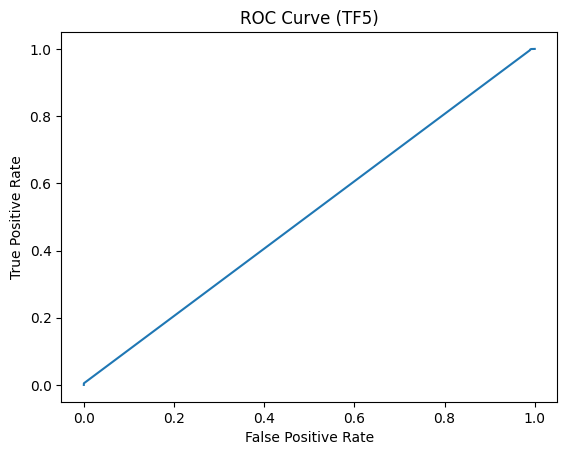

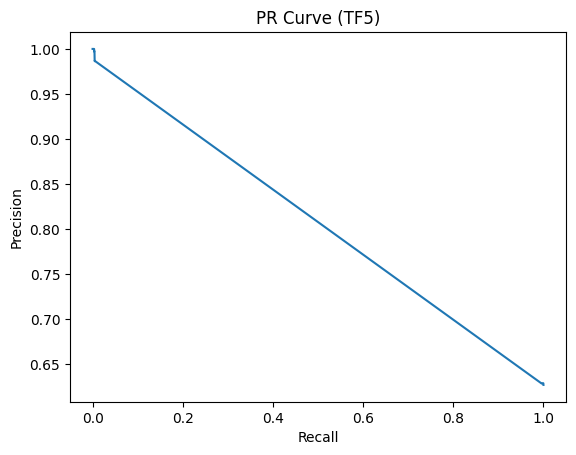

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC
fpr, tpr, _ = roc_curve(y_true, y_proba)
plt.plot(fpr, tpr)
plt.title("ROC Curve (TF5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# PR
precision, recall, _ = precision_recall_curve(y_true, y_proba)
plt.plot(recall, precision)
plt.title("PR Curve (TF5)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [38]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"\nThreshold: {t}")
    print("Precision:", precision_score(y_true, y_pred_t))
    print("Recall:", recall_score(y_true, y_pred_t))
    print("F1:", f1_score(y_true, y_pred_t))


Threshold: 0.3
Precision: 0.6288186687481495
Recall: 0.9992408122239925
F1: 0.7718898291434872

Threshold: 0.4
Precision: 0.6288555673011534
Recall: 0.9986740945883812
F1: 0.7717484713270534

Threshold: 0.5
Precision: 0.6287493345373434
Recall: 0.997658279958512
F1: 0.771365030548046

Threshold: 0.6
Precision: 0.6285498479238742
Recall: 0.9965890014007549
F1: 0.7708951952423884

Threshold: 0.7
Precision: 0.9926289926289926
Recall: 0.004319885373338608
F1: 0.008602333702410358


In [39]:
high_conf = (y_proba > 0.8) | (y_proba < 0.2)

print("High-confidence accuracy:",
      accuracy_score(y_true[high_conf], y_pred[high_conf]))

High-confidence accuracy: 0.9597222222222223
